# f6_m01a_shap_global.ipynb

## Qué hace
Calcula e interpreta la importancia global de features con SHAP sobre el conjunto de test.
Genera gráficos beeswarm, bar plot y heatmap para CatBoost, EBM y RF (los tres modelos
principales de Fase 5). Compara rankings de importancia entre los tres modelos.

## Requisitos
- `data/06_evaluacion/meta_test.parquet` (generado por f6_m00_preparacion)
- `data/05_modelado/models/` con CatBoost__balanced.pkl, EBM__balanced.pkl, RandomForest__balanced.pkl
- `data/05_modelado/X_test_prep.parquet` y `X_train_prep.parquet`
- Paquetes: shap, interpret, matplotlib, pandas, joblib

## Genera
- `results/fase6/shap_global_catboost.pkl` — shap_values CatBoost
- `results/fase6/shap_global_rf.pkl` — shap_values RF
- `results/fase6/ebm_importancia_global.parquet` — importancias nativas EBM
- `results/fase6/shap_importancia_comparativa.parquet` — rankings unificados CatBoost + RF + EBM
- `docs/html/fase6/m01a_shap_global.html`

## Flujo
Cargar datos → cargar modelos → SHAP TreeExplainer (CatBoost, RF) → EBM nativo →
gráficos → comparativa tres modelos → HTML

## Siguiente
`f6_m01b_shap_local.ipynb` — explicaciones individuales

In [1]:
# 1. CONFIGURACIÓN DE RUTAS Y ENTORNO
# ROOT detectado subiendo niveles hasta encontrar src/ — nunca hardcodeado
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

def _encontrar_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / 'src').is_dir():
            return parent
    raise FileNotFoundError('No se encontró src/ subiendo desde ' + str(start))

ROOT = _encontrar_root(Path.cwd())
sys.path.insert(0, str(ROOT))

# Rutas — modelos en data/05_modelado/models/, no en ROOT/models/
DIR_DATA       = ROOT / 'data' / '05_modelado'
DIR_EVALUACION = ROOT / 'data' / '06_evaluacion'
DIR_MODELS     = ROOT / 'data' / '05_modelado' / 'models'
DIR_RESULTS    = ROOT / 'results' / 'fase6'
DIR_RESULTS.mkdir(parents=True, exist_ok=True)

print(f'ROOT:          {ROOT}')
print(f'DIR_MODELS:    {DIR_MODELS}')
print(f'DIR_EVALUACION:{DIR_EVALUACION}')
print(f'DIR_RESULTS:   {DIR_RESULTS}')

ROOT:          C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI
DIR_MODELS:    C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\data\05_modelado\models
DIR_EVALUACION:C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\data\06_evaluacion
DIR_RESULTS:   C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\results\fase6


In [2]:
# 2. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import joblib
import shap
from src.html.render import render_pagina_desde_fichero
from src.utils.progress import spinner

# Configuración de visualización
matplotlib.rcParams['figure.dpi'] = 120
shap.initjs()  # necesario para gráficos interactivos SHAP en Jupyter

print('Imports OK.')

Imports OK.


In [3]:
# 3. CARGAR DATOS
# X_test_prep: features preprocesadas — las que recibe SHAP y TreeExplainer.
# y_test: etiquetas reales del conjunto de test.
# NOTA: meta_test contiene metadatos del alumno (titulacion, rama, etc.),
# NO probabilidades predichas — éstas se calculan con predict_proba en cada módulo.

X_test = pd.read_parquet(DIR_DATA / 'X_test_prep.parquet')
y_test = pd.read_parquet(DIR_DATA / 'y_test.parquet').squeeze()

feature_names = X_test.columns.tolist()

print(f'X_test:   {X_test.shape}')
print(f'y_test:   {y_test.shape}')
print(f'Features ({len(feature_names)}): {feature_names}')

X_test:   (6725, 19)
y_test:   (6725,)
Features (19): ['cred_superados_anio_1er', 'nota_1er_anio', 'nota_acceso', 'rama', 'sexo', 'edad_entrada', 'pais_nombre', 'provincia', 'via_acceso', 'orden_preferencia', 'universidad_origen', 'tuvo_beca', 'n_anios_beca', 'situacion_laboral', 'nota_selectividad', 'max_pagos', 'indicador_interrupcion', 'anios_gap', 'anios_sin_beca']


In [4]:
# 4. CARGAR MODELOS
# Convención Fase 5: NombreModelo__estrategia.pkl
# Usamos variante __balanced (mejor para clases desbalanceadas, 29.2% abandono)

def cargar_modelo(nombre_exacto: str):
    """Carga un modelo .pkl por nombre exacto desde DIR_MODELS."""
    ruta = DIR_MODELS / nombre_exacto
    if not ruta.exists():
        raise FileNotFoundError(f'No encontrado: {ruta}')
    print(f'  Cargando: {nombre_exacto}')
    return joblib.load(ruta)

print('Cargando modelos...')
modelo_catboost = cargar_modelo('CatBoost__balanced.pkl')
modelo_ebm      = cargar_modelo('EBM__balanced.pkl')
modelo_rf       = cargar_modelo('RandomForest__balanced.pkl')
print('Modelos cargados.')

Cargando modelos...
  Cargando: CatBoost__balanced.pkl


  Cargando: EBM__balanced.pkl


  Cargando: RandomForest__balanced.pkl

Modelos cargados.


In [5]:
# 5. CALCULAR SHAP — CATBOOST
# TreeExplainer: óptimo para modelos de árboles (CatBoost, RF, XGBoost).
# IMPORTANTE: los modelos de Fase 5 son sklearn.Pipeline con paso 'model'.
# TreeExplainer necesita el estimador en bruto, no el Pipeline completo.
# Extraemos con .named_steps['model'] antes de pasarlo a SHAP.
# Disk-first: si ya existe el .pkl guardado, lo carga directamente (~2-5 min ahorrados).

RUTA_SHAP_CAT = DIR_RESULTS / 'shap_global_catboost.pkl'

if RUTA_SHAP_CAT.exists():
    print('Cargando SHAP CatBoost desde disco...')
    shap_cat = joblib.load(RUTA_SHAP_CAT)
    print('Cargado.')
else:
    # Extraer CatBoostClassifier del Pipeline — paso llamado 'model'
    catboost_raw = modelo_catboost.named_steps['model']
    with spinner('Calculando SHAP CatBoost (TreeExplainer)...'):
        explainer_cat = shap.TreeExplainer(catboost_raw)
        shap_cat = explainer_cat(X_test)
        joblib.dump(shap_cat, RUTA_SHAP_CAT)
    print(f'SHAP CatBoost guardado en {RUTA_SHAP_CAT}')

Cargando SHAP CatBoost desde disco...
Cargado.


In [6]:
# 6. CALCULAR SHAP — RANDOM FOREST
# Igual que CatBoost: extraer el estimador raw del Pipeline con named_steps['model'].
# TreeExplainer es compatible con RandomForest de sklearn.

RUTA_SHAP_RF = DIR_RESULTS / 'shap_global_rf.pkl'

if RUTA_SHAP_RF.exists():
    print('Cargando SHAP RF desde disco...')
    shap_rf = joblib.load(RUTA_SHAP_RF)
    print('Cargado.')
else:
    # Extraer RandomForestClassifier del Pipeline
    rf_raw = modelo_rf.named_steps['model']
    with spinner('Calculando SHAP RF (TreeExplainer)...'):
        explainer_rf = shap.TreeExplainer(rf_raw)
        shap_rf = explainer_rf(X_test)
        joblib.dump(shap_rf, RUTA_SHAP_RF)
    print(f'SHAP RF guardado en {RUTA_SHAP_RF}')

Cargando SHAP RF desde disco...
Cargado.


In [7]:
# 7. IMPORTANCIAS EBM — MÉTODO NATIVO (sin SHAP genérico)
#
# EBM (Explainable Boosting Machine) ya tiene interpretabilidad incorporada por diseño.
# Internamente es una suma de funciones por feature: score = f1(x1) + f2(x2) + ...
# La contribución de cada feature es directamente calculable con explain_global().
# NO usamos shap.Explainer genérico sobre EBM: es un rodeo innecesario, más lento
# y con posibles incompatibilidades. El método nativo da el mismo resultado
# conceptual con mucho menos coste computacional.
# IMPORTANTE: igual que CatBoost y RF, EBM está dentro de un sklearn.Pipeline.
# explain_global() es método del EBM en bruto, no del Pipeline — extraer con named_steps.

RUTA_EBM_IMP = DIR_RESULTS / 'ebm_importancia_global.parquet'

if RUTA_EBM_IMP.exists():
    print('Cargando importancias EBM desde disco...')
    df_ebm_imp = pd.read_parquet(RUTA_EBM_IMP)
    print('Cargado.')
else:
    # Extraer EBM en bruto del Pipeline — paso llamado 'model'
    ebm_raw = modelo_ebm.named_steps['model']
    with spinner('Calculando importancias EBM (método nativo)...'):
        explicacion_global = ebm_raw.explain_global()
        datos_ebm = explicacion_global.data()

        # datos_ebm es un dict con 'names' e 'scores'
        # 'scores' son las importancias medias por feature (ya en escala absoluta)
        nombres_ebm = datos_ebm['names']
        scores_ebm  = datos_ebm['scores']

        df_ebm_imp = pd.DataFrame({
            'feature':    nombres_ebm,
            'importancia': scores_ebm
        }).set_index('feature').sort_values('importancia', ascending=False)

        df_ebm_imp.to_parquet(RUTA_EBM_IMP)
    print(f'Importancias EBM guardadas en {RUTA_EBM_IMP}')

print(f'Top 5 EBM: {df_ebm_imp.head().index.tolist()}')

Cargando importancias EBM desde disco...
Cargado.
Top 5 EBM: ['n_anios_beca', 'anios_sin_beca', 'situacion_laboral', 'cred_superados_anio_1er', 'nota_1er_anio']


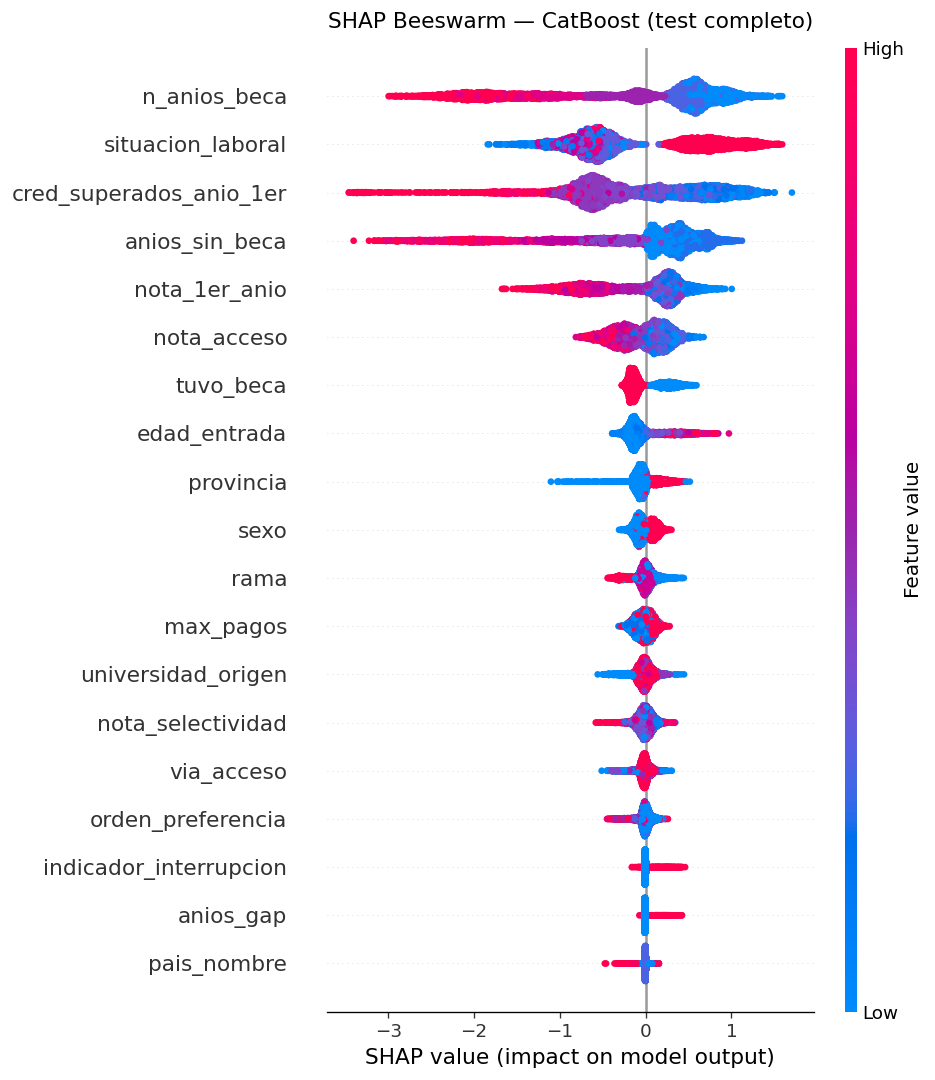

Beeswarm CatBoost guardado.


In [8]:
# 8. GRÁFICO 1 — BEESWARM CATBOOST
# Cada punto = una observación. Eje X = valor SHAP (impacto en predicción).
# Color = valor de la feature (rojo=alto, azul=bajo).
# Features ordenadas de mayor a menor importancia media.

fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.beeswarm(shap_cat, max_display=19, show=False)
plt.title('SHAP Beeswarm — CatBoost (test completo)', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(DIR_RESULTS / 'shap_beeswarm_catboost.png', dpi=120, bbox_inches='tight')
plt.show()
print('Beeswarm CatBoost guardado.')

In [9]:
# 9. FUNCIÓN AUXILIAR — EXTRAER IMPORTANCIAS SHAP
# Calcula media de |SHAP| por feature a partir de un objeto Explanation de SHAP.
# Compatible con shape (n, p) y (n, p, 2) — este último para clasificación binaria.

def importancia_shap(shap_values, nombres_features) -> pd.Series:
    """Devuelve media de |SHAP| por feature, ordenada descendente."""
    vals = shap_values.values if hasattr(shap_values, 'values') else shap_values
    # Para clasificación binaria puede tener shape (n, p, 2) → tomar clase 1 (abandono)
    if vals.ndim == 3:
        vals = vals[:, :, 1]
    imp = np.abs(vals).mean(axis=0)
    return pd.Series(imp, index=nombres_features).sort_values(ascending=False)

imp_cat = importancia_shap(shap_cat, feature_names)
imp_rf  = importancia_shap(shap_rf,  feature_names)

# Alinear EBM con las mismas features (puede haber diferencias de nombre)
imp_ebm = df_ebm_imp['importancia'].reindex(feature_names).fillna(0)

print('Importancias calculadas para los tres modelos.')

Importancias calculadas para los tres modelos.


In [10]:
# 10. TABLA COMPARATIVA — TRES MODELOS
# Rankings unificados: CatBoost, RF y EBM.
# Permite identificar consenso (features top en los tres) y discrepancias.

df_imp = pd.DataFrame({
    'CatBoost': imp_cat,
    'RF':       imp_rf,
    'EBM':      imp_ebm
}).fillna(0)

df_imp['rank_cat'] = df_imp['CatBoost'].rank(ascending=False).astype(int)
df_imp['rank_rf']  = df_imp['RF'].rank(ascending=False).astype(int)
df_imp['rank_ebm'] = df_imp['EBM'].rank(ascending=False).astype(int)

# Rango medio como medida de consenso global
df_imp['rank_medio'] = (df_imp['rank_cat'] + df_imp['rank_rf'] + df_imp['rank_ebm']) / 3

df_imp.to_parquet(DIR_RESULTS / 'shap_importancia_comparativa.parquet')
print('Comparativa guardada.')
print('\nTop 10 por rango medio (consenso tres modelos):')
print(df_imp.nsmallest(10, 'rank_medio')[['CatBoost','RF','EBM','rank_cat','rank_rf','rank_ebm']].to_string())

Comparativa guardada.

Top 10 por rango medio (consenso tres modelos):
                         CatBoost        RF       EBM  rank_cat  rank_rf  rank_ebm
n_anios_beca             0.921817  0.119500  1.065298         1        1         1
anios_sin_beca           0.623520  0.076593  0.888519         4        3         2
cred_superados_anio_1er  0.670537  0.105516  0.674148         3        2         4
situacion_laboral        0.708595  0.073713  0.687314         2        4         3
nota_1er_anio            0.441873  0.063360  0.474429         5        5         5
nota_acceso              0.238521  0.038673  0.342300         6        6         6
tuvo_beca                0.181464  0.025714  0.217366         7        7         8
edad_entrada             0.168003  0.021185  0.288157         8        8         7
sexo                     0.086438  0.009287  0.119209        10       10        10
max_pagos                0.078417  0.005656  0.123900        12       11         9


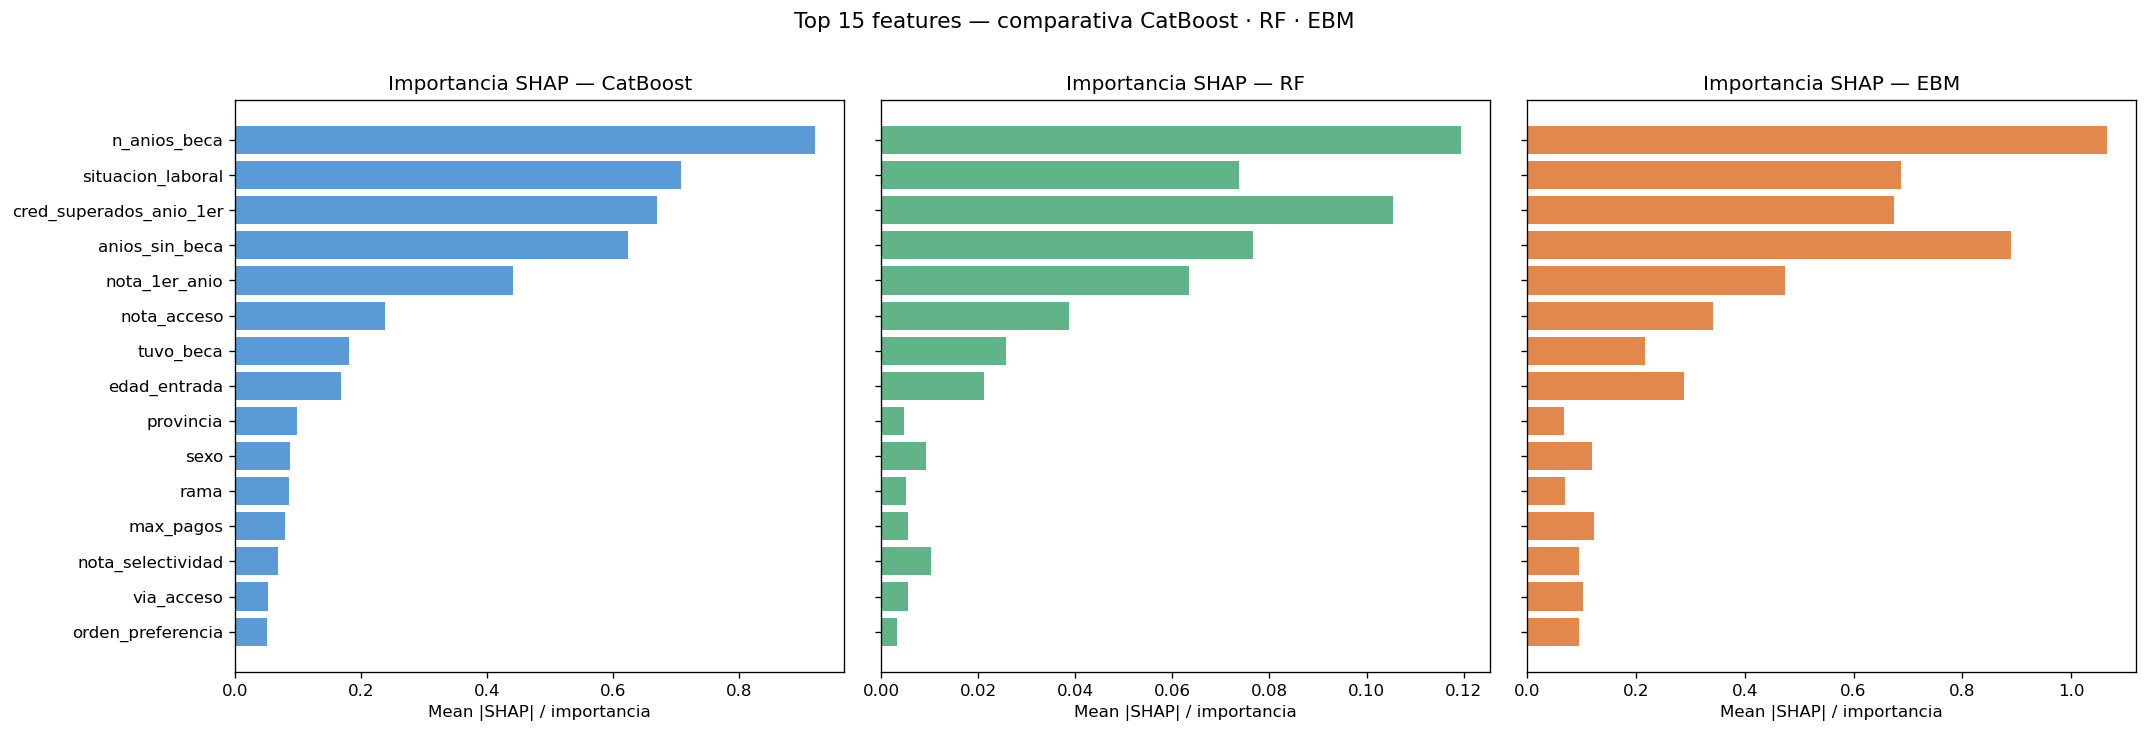

Bar plot comparativo guardado.


In [11]:
# 11. GRÁFICO 2 — BAR PLOT COMPARATIVO TRES MODELOS
# Importancia media |SHAP| (y nativa EBM) para top 15 features.
# Azul = CatBoost, verde = RF, naranja = EBM.

top_n = 15
features_top = df_imp.nsmallest(top_n, 'rank_medio').index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
colores = ['#3182ce', '#38a169', '#dd6b20']
modelos = ['CatBoost', 'RF', 'EBM']

for ax, modelo, color in zip(axes, modelos, colores):
    vals = df_imp.loc[features_top, modelo].sort_values()
    ax.barh(vals.index, vals.values, color=color, alpha=0.8)
    ax.set_title(f'Importancia SHAP — {modelo}', fontsize=12)
    ax.set_xlabel('Mean |SHAP| / importancia')

plt.suptitle(f'Top {top_n} features — comparativa CatBoost · RF · EBM', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(DIR_RESULTS / 'shap_bar_comparativo.png', dpi=120, bbox_inches='tight')
plt.show()
print('Bar plot comparativo guardado.')

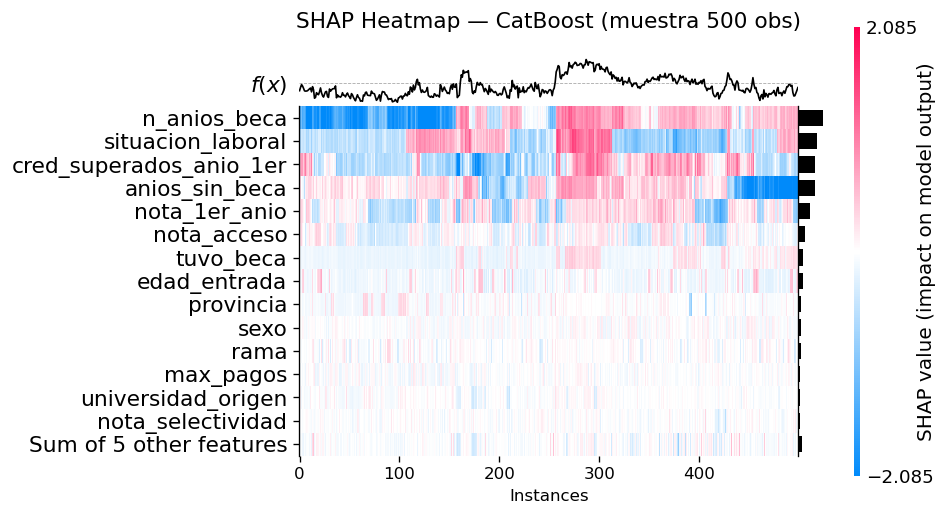

Heatmap guardado.


In [12]:
# 12. GRÁFICO 3 — HEATMAP SHAP (CatBoost)
# Mapa de calor de valores SHAP por observación y feature.
# Usamos muestra de 500 obs — shap.plots.heatmap hace clustering O(n²)
# sobre todas las observaciones, lo que con 6.725 filas tarda varios minutos.
# 500 obs es suficiente para mostrar los patrones correctamente.

idx_muestra  = np.random.default_rng(42).choice(len(shap_cat), size=500, replace=False)
shap_muestra = shap_cat[idx_muestra]

fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.heatmap(shap_muestra, max_display=15, show=False)
plt.title('SHAP Heatmap — CatBoost (muestra 500 obs)', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(DIR_RESULTS / 'shap_heatmap_catboost.png', dpi=120, bbox_inches='tight')
plt.show()
print('Heatmap guardado.')

In [13]:
# 13. ANÁLISIS DE DISCREPANCIAS ENTRE MODELOS
# Features donde los tres modelos discrepan más en importancia relativa.
# Discrepancia = rango máximo - rango mínimo entre los tres modelos.

df_imp['discrepancia'] = (
    df_imp[['rank_cat', 'rank_rf', 'rank_ebm']].max(axis=1) -
    df_imp[['rank_cat', 'rank_rf', 'rank_ebm']].min(axis=1)
)

print('Top 5 features con MAYOR CONSENSO (todos los modelos de acuerdo):')
print(df_imp.nsmallest(5, 'discrepancia')[['rank_cat','rank_rf','rank_ebm','discrepancia']].to_string())

print('\nTop 5 features con MAYOR DISCREPANCIA (modelos en desacuerdo):')
print(df_imp.nlargest(5, 'discrepancia')[['rank_cat','rank_rf','rank_ebm','discrepancia']].to_string())

Top 5 features con MAYOR CONSENSO (todos los modelos de acuerdo):
               rank_cat  rank_rf  rank_ebm  discrepancia
anios_gap            18       18        18             0
n_anios_beca          1        1         1             0
nota_1er_anio         5        5         5             0
nota_acceso           6        6         6             0
pais_nombre          19       19        19             0

Top 5 features con MAYOR DISCREPANCIA (modelos en desacuerdo):
                    rank_cat  rank_rf  rank_ebm  discrepancia
provincia                  9       15        15             6
nota_selectividad         14        9        13             5
orden_preferencia         16       16        12             4
universidad_origen        13       14        17             4
via_acceso                15       12        11             4


In [14]:
# 14. GENERAR HTML
# Imágenes embebidas en base64. Tabla con top 10 por consenso.
# Usar render_pagina_desde_fichero — estándar del proyecto.

import base64

def img_b64(ruta: Path) -> str:
    """Devuelve imagen como string base64 para incrustar en HTML."""
    if not ruta.exists():
        return ''
    with open(ruta, 'rb') as f:
        return base64.b64encode(f.read()).decode()

def bloque_imagen(b64: str, titulo: str, caption: str) -> str:
    if not b64:
        return f'<p style="color:#e53e3e">Imagen no disponible: {titulo}</p>'
    return (
        '<div style="margin:24px 0">'
        f'<h3 style="color:#2d3748; font-size:15px">{titulo}</h3>'
        f'<img src="data:image/png;base64,{b64}" style="max-width:100%; border-radius:6px; box-shadow:0 2px 8px rgba(0,0,0,.1)">'
        f'<p style="color:#718096; font-size:12px; margin-top:6px">{caption}</p>'
        '</div>'
    )

b64_beeswarm = img_b64(DIR_RESULTS / 'shap_beeswarm_catboost.png')
b64_bar      = img_b64(DIR_RESULTS / 'shap_bar_comparativo.png')
b64_heatmap  = img_b64(DIR_RESULTS / 'shap_heatmap_catboost.png')

# Tabla top 10 por consenso
top10 = df_imp.nsmallest(10, 'rank_medio').reset_index()
filas_tabla = ''
for _, row in top10.iterrows():
    filas_tabla += (
        '<tr>'
        f'<td style="padding:7px 12px; font-weight:600">{row["index"]}</td>'
        f'<td style="padding:7px 12px; text-align:right">{row["CatBoost"]:.4f}</td>'
        f'<td style="padding:7px 12px; text-align:right">{int(row["rank_cat"])}</td>'
        f'<td style="padding:7px 12px; text-align:right">{row["RF"]:.4f}</td>'
        f'<td style="padding:7px 12px; text-align:right">{int(row["rank_rf"])}</td>'
        f'<td style="padding:7px 12px; text-align:right">{row["EBM"]:.4f}</td>'
        f'<td style="padding:7px 12px; text-align:right">{int(row["rank_ebm"])}</td>'
        f'<td style="padding:7px 12px; text-align:right">{row["rank_medio"]:.1f}</td>'
        '</tr>'
    )

contenido = (
    '<h2 style="color:#2d3748">SHAP Global — Importancia de Features</h2>'
    '<p style="color:#4a5568; font-size:14px; max-width:800px">'
    'Análisis de importancia global con SHAP (<em>SHapley Additive exPlanations</em>) sobre '
    'el conjunto de test completo. Se comparan CatBoost y RF mediante TreeExplainer, y EBM '
    'mediante su método nativo de interpretabilidad. Los valores representan la contribución '
    'media absoluta de cada feature a la predicción de cada modelo.'
    '</p>'
    + bloque_imagen(b64_beeswarm,
        'Beeswarm plot — CatBoost',
        'Cada punto es una observación. Eje X = valor SHAP (impacto en predicción). '
        'Color = valor de la feature (rojo=alto, azul=bajo). '
        'Features ordenadas de mayor a menor importancia media.')
    + bloque_imagen(b64_bar,
        'Bar plot comparativo — CatBoost · RF · EBM',
        'Importancia media por feature en los tres modelos. '
        'Permite identificar consenso (features top en los tres) y discrepancias.')
    + bloque_imagen(b64_heatmap,
        'Heatmap SHAP — CatBoost',
        'Mapa de calor de valores SHAP por observación y feature. '
        'Permite identificar patrones de comportamiento del modelo.')
    + '<h3 style="color:#2d3748; margin-top:28px">Top 10 features — consenso tres modelos</h3>'
    + '<table style="width:100%; border-collapse:collapse; font-size:13px">'
    + '<thead><tr style="background:#edf2f7">'
    + '<th style="padding:7px 12px; text-align:left">Feature</th>'
    + '<th style="padding:7px 12px; text-align:right">SHAP Cat</th>'
    + '<th style="padding:7px 12px; text-align:right">Rank Cat</th>'
    + '<th style="padding:7px 12px; text-align:right">SHAP RF</th>'
    + '<th style="padding:7px 12px; text-align:right">Rank RF</th>'
    + '<th style="padding:7px 12px; text-align:right">Imp EBM</th>'
    + '<th style="padding:7px 12px; text-align:right">Rank EBM</th>'
    + '<th style="padding:7px 12px; text-align:right">Rank medio</th>'
    + '</tr></thead>'
    + f'<tbody>{filas_tabla}</tbody></table>'
    + '<div style="margin-top:24px; padding:16px; background:#ebf8ff; '
    + 'border-left:4px solid #3182ce; border-radius:6px; font-size:13px; color:#2c5282">'
    + '<strong>Interpretación:</strong> Las features con menor rango medio tienen importancia '
    + 'consensuada entre los tres modelos — son los hallazgos más robustos. '
    + 'Las features con alta discrepancia de rango son específicas de cada algoritmo '
    + 'y requieren análisis individual antes de incluirlas en conclusiones.'
    + '</div>'
)

# render_pagina_desde_fichero — estándar del proyecto (infiere fase/módulo del nombre)
html_completo = render_pagina_desde_fichero('f6_m01a_shap_global.ipynb', contenido)
ruta_html = ROOT / 'docs' / 'html' / 'fase6' / 'm01a_shap_global.html'
ruta_html.parent.mkdir(parents=True, exist_ok=True)
ruta_html.write_text(html_completo, encoding='utf-8')
print(f'HTML generado: {ruta_html}')

HTML generado: C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\docs\html\fase6\m01a_shap_global.html
